## Optimise coeffs from DEAP output

In [59]:
import os
import polars as pl
from scipy.optimize import minimize, basinhopping
import numpy as np
import matplotlib.pyplot as plt

## Load data

Patient demographics by MSOA:

In [60]:
path_to_msoa_stats = os.path.join('..', 'data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [61]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [62]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [63]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [64]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [65]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [66]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [67]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [68]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [69]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [70]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

Pick out just the values for the left edges of the bins:

In [71]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [72]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [73]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [74]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


In [75]:
qmin_list = np.round(np.arange(0.0, 1.0, 0.2), 1)

In [76]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

## Start coeffs

from DEAP results

In [77]:
# from previous notebook
coeffs_ssnap = [0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

In [78]:
df_best_gens = pl.read_csv(os.path.join('outputs', 'best_inds_deap.csv'))

In [79]:
df_best_gens.sort('r2_all', descending=True)

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",59.0,1.46312,1.695159,1.205551,1.19339,1.202789,1.19011,1.183463,1.2,1.19339,1.10153,0.960694,0.997975,1.0,1.0,1.080779,0.85047,0.799606,0.974258,0.998259,1.0,0.808107,0.793863,0.899786,0.8,0.930343,239.287371,0.59191,0.496018,0.579529,0.638646,0.607951,0.615709
"""randomseed41""",35.0,1.4,1.394472,1.491289,1.2,1.176441,1.253797,1.173068,1.080715,1.050118,1.125261,1.0,1.053346,1.0,1.0,1.0,0.8,0.961484,1.0,1.0,1.0,0.8,0.8,0.8,0.908886,0.982146,240.136292,0.591804,0.494457,0.58296,0.634319,0.606642,0.619415
"""randomseed47""",51.0,1.509935,1.288461,1.327035,1.33879,1.2,1.113402,1.198,1.2,1.125237,1.12347,0.992264,1.05886,1.0,1.016319,1.0,0.902984,0.926627,0.939284,0.958704,0.988581,0.755995,0.889544,0.863378,0.819027,0.988581,240.268793,0.591575,0.494178,0.579535,0.634652,0.607894,0.620379
"""randomseed65""",58.0,1.384298,1.707645,1.6,1.088252,1.180937,1.202216,1.18193,1.2,1.088252,1.110136,0.988208,1.0,1.0,1.0,1.019277,0.912351,0.987298,0.96661,0.970934,0.99073,0.79201,0.6,0.697933,0.969452,0.981982,240.477538,0.591558,0.494306,0.581535,0.635265,0.605752,0.619604
"""randomseed81""",30.0,1.474497,1.4,1.4,1.107886,1.2,1.106899,1.2,1.183136,1.107886,1.184099,0.995979,1.0,1.0,1.0,1.02665,0.89788,0.974566,0.993429,1.0,0.950901,0.799854,0.790744,0.8,0.928723,0.950901,241.679306,0.591511,0.496688,0.577989,0.636342,0.606189,0.619144
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed60""",23.0,1.4,1.391014,1.4,1.4,1.269015,1.187818,1.2,1.2,1.2,1.2,1.0,1.0,0.977735,1.0,1.0,0.890014,1.0,0.977735,0.880251,0.942276,0.795935,0.8,0.8,0.8,0.927973,241.734051,0.58279,0.486058,0.562332,0.632282,0.602063,0.609088
"""randomseed83""",25.0,1.322617,1.350996,1.341558,1.4,1.278371,1.155608,1.2,1.2,1.2,1.184784,1.0,1.067706,1.0,0.9933,1.0,1.0,1.0,0.994465,0.874328,1.0,0.8,0.741061,0.8,0.8,0.883632,243.415986,0.581689,0.491031,0.56937,0.63435,0.60288,0.588041
"""randomseed98""",34.0,1.4,1.385308,1.309416,1.4,1.32992,1.2,1.2,1.068135,1.041676,1.215415,1.0,1.0,1.0,1.0,0.999982,0.868196,1.0,1.0,0.953337,0.999399,0.8,0.80838,0.909831,0.8,0.838122,243.918821,0.581656,0.481074,0.578695,0.63315,0.605913,0.585607


In [80]:
mask = np.round(df_best_gens['r2_all'], 3) == np.round(df_best_gens['r2_all'].max(), 3)

best_dirs = df_best_gens.filter(mask)['dir'].to_numpy()

best_dirs

array(['randomseed04', 'randomseed41', 'randomseed47', 'randomseed65',
       'randomseed81'], dtype=object)

In [165]:
best_dirs = df_best_gens.sort('r2_all', descending=True)['dir'].to_numpy()

In [166]:
best_dirs

array(['randomseed04', 'randomseed41', 'randomseed47', 'randomseed65',
       'randomseed81', 'randomseed17', 'randomseed34', 'randomseed52',
       'randomseed09', 'randomseed55', 'randomseed64', 'randomseed02',
       'randomseed56', 'randomseed71', 'randomseed70', 'randomseed80',
       'randomseed76', 'randomseed94', 'randomseed03', 'randomseed12',
       'randomseed53', 'randomseed82', 'randomseed32', 'randomseed13',
       'randomseed40', 'randomseed16', 'randomseed36', 'randomseed29',
       'randomseed24', 'randomseed99', 'randomseed74', 'randomseed11',
       'randomseed50', 'randomseed27', 'randomseed19', 'randomseed26',
       'randomseed18', 'randomseed67', 'randomseed49', 'randomseed58',
       'randomseed66', 'randomseed01', 'randomseed89', 'randomseed93',
       'randomseed45', 'randomseed35', 'randomseed90', 'randomseed46',
       'randomseed69', 'randomseed14', 'randomseed96', 'randomseed87',
       'randomseed44', 'randomseed21', 'randomseed22', 'randomseed37',
      

In [162]:
# Store start combos of coeffs in here:
coeffs_init_start = {}

for d, best_dir in enumerate(best_dirs):
    scales_init = df_best_gens.filter(df_best_gens['dir'] == best_dir)[coeff_names].to_numpy()[0]
    coeffs_init = [s for s in scales_init]
    for c, coeff in enumerate(coeffs_ssnap):
        for i in range(5):
            coeffs_init[5*i + c] *= coeff
    coeffs_init_start[best_dir] = coeffs_init

# coeffs_init_grid = np.array(coeffs_init).reshape(5, 5)
# # To get all coeffs for one age band:        coeffs_init_grid[:, 0]
# # To get all coeffs for one depriv quantile: coeffs_init_grid[0, :]

In [110]:
df_coeffs_init = pl.concat([pl.DataFrame([c], schema=coeff_names) for c in coeffs_init_start.values()]).cast(float)

df_coeffs_init = df_coeffs_init.with_columns(pl.Series('coeff_combo', coeffs_init_start.keys()))#.cast(int))
# Move this column to start:
df_coeffs_init = df_coeffs_init.drop('coeff_combo').insert_column(0, df_coeffs_init.get_column('coeff_combo'))


In [111]:
df_coeffs_init

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.000597,0.004482,0.004503,0.007166,0.013902,0.000486,0.003129,0.004482,0.007166,0.012731,0.000392,0.002639,0.003735,0.006005,0.012492,0.000347,0.002114,0.003639,0.005995,0.011558,0.00033,0.002099,0.003361,0.004804,0.010753
"""randomseed41""",0.0005712,0.003687,0.00557,0.007206,0.013597,0.000512,0.003102,0.004036,0.006306,0.013006,0.000408,0.002785,0.003735,0.006005,0.011558,0.0003264,0.002542,0.003735,0.006005,0.011558,0.0003264,0.002115,0.002988,0.005458,0.011352
"""randomseed47""",0.000616,0.003407,0.004956,0.008039,0.01387,0.000454,0.003168,0.004482,0.006757,0.012985,0.000405,0.0028,0.003735,0.006103,0.011558,0.000368,0.00245,0.003508,0.005757,0.011426,0.000308,0.002352,0.003225,0.004918,0.011426
"""randomseed65""",0.000565,0.004515,0.005976,0.006535,0.013649,0.000491,0.003125,0.004482,0.006535,0.012831,0.000403,0.002644,0.003735,0.006005,0.011781,0.000372,0.00261,0.00361,0.00583,0.011451,0.000323,0.0015864,0.002607,0.005822,0.01135
"""randomseed81""",0.000602,0.003702,0.005229,0.006653,0.01387,0.000452,0.0031728,0.004419,0.006653,0.013686,0.000406,0.002644,0.003735,0.006005,0.011866,0.000366,0.002577,0.00371,0.006005,0.010991,0.000326,0.002091,0.002988,0.005577,0.010991


In [95]:
dict_admissions_age = {
    "Under 65": 18737.66819,
    "65-69": 7395.26689,
    "70-74": 10379.62674,
    "75-79": 11654.63948,
    "80 and over": 32790.7987,
}
admissions_by_age = list(dict_admissions_age.values())

## Function for optimising

In [97]:
def main_opt(coeffs, args):
    all_calculated_admissions = []
    all_observed_admissions = sum([list(a) for a in args[1]], [])

    coeffs = np.round(coeffs, 7)


    x_lists = args[0]
    admissions_by_age = args[2]
    # coeffs_ssnap = args[3]
    # Predictions for each age band across England:
    predictions_by_age = [0.0] * 5
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs_here = coeffs[(i*5):(i*5)+5] #* np.array(coeffs_ssnap)
        yhat_list = predict_admissions_each_age(x_lists_here, coeffs_here)
        # predictions_lists.append(yhat)
        for j, y in enumerate(yhat_list):
            predictions_by_age[j] += y
    # Divide the admissions by age band by the observed values:
    for j in range(len(predictions_by_age)):
        predictions_by_age[j] /= admissions_by_age[j]
    # Wrongness ratio factor:
    rat = sum(np.abs(np.array(predictions_by_age) - 1.0)) + 1.0

    
    coeffs_grid = np.array(coeffs).reshape(5, 5)
    for i, q in enumerate(qmin_list):
        coeffs_q = coeffs_grid[i, :]
        x_lists = args[0][i]
        admissions = args[1][i]
        
        calculated_admissions = predict_admissions(x_lists, np.array(coeffs_q))

        all_calculated_admissions += list(calculated_admissions)

    # Calculate measure of difference from the observed admissions:
    # print(
    #     np.array(all_calculated_admissions),
    #     np.array(all_observed_admissions)
    # )
    # diff = find_mean_abs_diff(
    diff = find_square_residuals(
        np.array(all_calculated_admissions),
        np.array(all_observed_admissions)
    )
    # Apply wrongness factor:
    diff *= rat

    
    diff_before = diff
    n_penalty = 0
    use_penalty = True
    if use_penalty:
        # Check coefficient conditions. If any aren't met, add a penalty
        # to the main difference measure.
        n_decrease = 0.0
        for i, q in enumerate(qmin_list):
            # Pick out coeffs for this depriv quantile:
            coeffs_q = coeffs_grid[i, :]
            # Do all coeffs increase with age band?
            n_decrease += sum(np.sign(np.diff(coeffs_q)) < 0)

        n_increase = 0.0
        for i, a in enumerate(age_numbers):
            # Pick out coeffs for this age band:
            coeffs_q = coeffs_grid[:, i]
            # Do all coeffs decrease with depriv quantile?
            n_increase += sum(np.sign(np.diff(coeffs_q)) > 0)

        # Add penalty:
        n_penalty = n_increase + n_decrease
        if n_penalty > 0.0:
            diff += (n_penalty * abs(diff) * 0.2)
    # print(diff_before, n_penalty, diff)
    # print(coeffs_grid)
    # # print(n_decrease, n_increase, diff)
    # print('\n' * 3)

    return diff

In [84]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    return yhat

In [85]:
def predict_admissions_each_age(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    # yhat = [(x_lists[i] * coeffs[i]).to_numpy() for i in range(len(coeffs))]
    yhat = (
        [(x_lists[i] * coeffs[i]).sum() for i in range(len(coeffs))]
    )
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [86]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (yhat - y)**2.0
    # Sum of differences:
    sum_sqres = np.sqrt(sqres.sum())
    return sum_sqres

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [87]:
def find_mean_abs_diff(yhat, y):
    # Difference from actual:
    absres = np.abs((yhat - y))
    # Mean of differences:
    mean_absres = absres.mean()
    return mean_absres

To check accuracy, the following function calculates R-squared:

In [88]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

## Run grid

In [91]:
all_x_lists = []
all_admissions = []

for qmin in qmin_list:
    mask = (df_stats['depriv_quantile_min'] == qmin)
    # Keep only those MSOA:
    df_stats_here = df_stats.filter(mask)
    # MSOA data in the same order as those coefficients:
    x_lists = [df_stats_here[a] for a in age_numbers]
    admissions = df_stats_here['admissions'].to_numpy()
    all_x_lists.append(x_lists)
    all_admissions.append(admissions)

In [98]:
dict_coeffs = {}
dict_opt_results = {}
# Store these opt results keys:
opt_results_keys = ['message', 'success', 'status', 'nit', 'nfev']

i = 1
for coeff_combo, coeffs_init in coeffs_init_start.items():
    print(f'{i:5d} out of {len(coeffs_init_start)}', end='\r')
    i += 1
    bounds_here = [(0.0, 1.0)] * len(coeffs_init)  # force results to lie between 0 and 1
    
        
    # Run the optimiser:
    opt_results = minimize(
        main_opt,
        x0=coeffs_init,
        args=[all_x_lists, all_admissions, admissions_by_age],
        bounds=bounds_here,
        method='Nelder-Mead',
        # method='SLSQP',
        options=dict(maxiter=10000),
    )
    # Pick out the resulting health coefficients:
    coeffs = np.round(opt_results['x'], 7)

    # Calculate R^2 here:

    # Log whether this combo optimised successfully:
    dict_opt_results[coeff_combo] = pl.DataFrame(np.array([[f'{coeff_combo}'] + [opt_results[k] for k in opt_results_keys]]), schema=['coeff_combo'] + opt_results_keys)
    # pl.Series(f'{coeff_combo}', [opt_results[k] for k in opt_results_keys], strict=False).to_frame()
    # Store coeffs:
    dict_coeffs[coeff_combo] = pl.DataFrame(np.array([[f'{coeff_combo}'] + list(coeffs)]), schema=['coeff_combo'] + coeff_names)
    # pl.Series(f'{coeff_combo}', coeffs).to_frame()

Gather results into dataFrames:

In [ ]:
df_opt_results = pl.concat(dict_opt_results.values())

# df_opt_results = df_opt_results.with_columns(pl.Series('coeff_combo', df_opt_results['coeff_combo'].cast(int)))

In [100]:
df_opt_results

coeff_combo,message,success,status,nit,nfev
str,str,str,str,str,str
"""randomseed04""","""Optimization terminated succes…","""True""","""0""","""438""","""869"""
"""randomseed41""","""Optimization terminated succes…","""True""","""0""","""555""","""979"""
"""randomseed47""","""Optimization terminated succes…","""True""","""0""","""504""","""968"""
"""randomseed65""","""Optimization terminated succes…","""True""","""0""","""499""","""933"""
"""randomseed81""","""Optimization terminated succes…","""True""","""0""","""580""","""1004"""


In [106]:
df_coeffs = pl.concat(dict_coeffs.values())#.cast(float)

# df_coeffs = df_coeffs.with_columns(pl.Series('coeff_combo', df_coeffs['coeff_combo'].cast(int)))
for c in coeff_names:
    df_coeffs = df_coeffs.with_columns(pl.Series(c, df_coeffs[c].cast(float)))

In [107]:
df_coeffs

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.0005943,0.0044859,0.0045138,0.007188,0.0139038,0.0004852,0.0031233,0.0044872,0.0071635,0.0126489,0.0003905,0.0026363,0.0037408,0.0060114,0.0124872,0.000349,0.0021195,0.0036495,0.0059937,0.0115054,0.0003314,0.0021014,0.0033617,0.0048194,0.0107622
"""randomseed41""",0.0005711,0.0036941,0.0055439,0.0071915,0.013603,0.0005125,0.0031065,0.0040363,0.0062997,0.0130672,0.0004109,0.0027873,0.0037476,0.0060181,0.0115882,0.0003293,0.0025422,0.0037173,0.0059698,0.011566,0.0003262,0.0021283,0.0029849,0.0054645,0.0113556
"""randomseed47""",0.000613,0.0034109,0.0049707,0.0079223,0.0138519,0.0004518,0.0031676,0.004481,0.0066927,0.0129607,0.0004066,0.0027992,0.0037416,0.0060326,0.0116013,0.0003699,0.0024579,0.0034959,0.0057663,0.0114467,0.0003093,0.0023638,0.0032348,0.0049349,0.0113895
"""randomseed65""",0.0005597,0.0044858,0.0059303,0.0065995,0.0136842,0.0004901,0.0031015,0.0044538,0.0065356,0.0128348,0.0004066,0.0026388,0.0036866,0.0059569,0.0119035,0.0003722,0.0026107,0.0036075,0.0058368,0.0113949,0.0003256,0.0016134,0.0025957,0.0058287,0.011366
"""randomseed81""",0.0005925,0.0036624,0.0052648,0.0065693,0.0139197,0.0004519,0.0031534,0.0041839,0.0065518,0.0135912,0.0004038,0.0026694,0.0037936,0.0061147,0.0119159,0.0003697,0.0026204,0.0036869,0.0059019,0.0111037,0.0003357,0.0021464,0.0030361,0.0056294,0.0109578


In [113]:
df_coeffs_init

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.000597,0.004482,0.004503,0.007166,0.013902,0.000486,0.003129,0.004482,0.007166,0.012731,0.000392,0.002639,0.003735,0.006005,0.012492,0.000347,0.002114,0.003639,0.005995,0.011558,0.00033,0.002099,0.003361,0.004804,0.010753
"""randomseed41""",0.0005712,0.003687,0.00557,0.007206,0.013597,0.000512,0.003102,0.004036,0.006306,0.013006,0.000408,0.002785,0.003735,0.006005,0.011558,0.0003264,0.002542,0.003735,0.006005,0.011558,0.0003264,0.002115,0.002988,0.005458,0.011352
"""randomseed47""",0.000616,0.003407,0.004956,0.008039,0.01387,0.000454,0.003168,0.004482,0.006757,0.012985,0.000405,0.0028,0.003735,0.006103,0.011558,0.000368,0.00245,0.003508,0.005757,0.011426,0.000308,0.002352,0.003225,0.004918,0.011426
"""randomseed65""",0.000565,0.004515,0.005976,0.006535,0.013649,0.000491,0.003125,0.004482,0.006535,0.012831,0.000403,0.002644,0.003735,0.006005,0.011781,0.000372,0.00261,0.00361,0.00583,0.011451,0.000323,0.0015864,0.002607,0.005822,0.01135
"""randomseed81""",0.000602,0.003702,0.005229,0.006653,0.01387,0.000452,0.0031728,0.004419,0.006653,0.013686,0.000406,0.002644,0.003735,0.006005,0.011866,0.000366,0.002577,0.00371,0.006005,0.010991,0.000326,0.002091,0.002988,0.005577,0.010991


Check result:

In [114]:
qmin_list = np.round(qmin_list, 1)

In [115]:
list_r2_dicts = []

for coeff_combo in df_coeffs['coeff_combo']:
    dict_r2 = {}
    mask = df_coeffs['coeff_combo'] == coeff_combo
    row_coeffs = df_coeffs.filter(mask)

    df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))
    
    for q in qmin_list:
        qstr = str(round(q, 1)).replace('.', '')
        df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)
        
        for a in age_numbers:
            df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (row_coeffs[f'{a}_q{qstr}'].to_numpy()[0] * df_here[a])))

        # R2 for just this q:
        r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
        dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)
        
        mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])

        # df_admissions_here = df_admissions_here.with_columns(
        #    pl.when(mask)
        #      .then(df_here['admissions_predicted'])
        #      .otherwise(pl.col('admissions_predicted'))
        #      .name.keep()
        # )
        df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
        
    cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))
    
    # Calculate R2:
    r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
    dict_r2['r2_all'] = np.round(r2, 5)
    # Calculate residuals:
    res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
    dict_r2['res'] = np.round(res, 3)
            

    list_r2_dicts.append(pl.DataFrame([[coeff_combo] + list(dict_r2.values())], schema=['coeff_combo'] + list(dict_r2.keys())))

In [116]:
# Convert results to dataframe:
df_r2 = pl.concat(list_r2_dicts, how='vertical')

In [117]:
df_r2

coeff_combo,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.496,0.58,0.63865,0.60782,0.61611,0.59205,237.872
"""randomseed41""",0.4944,0.58288,0.63506,0.60678,0.61932,0.59195,237.901
"""randomseed47""",0.49496,0.57926,0.63493,0.60791,0.62019,0.59169,237.978
"""randomseed65""",0.49441,0.58167,0.63621,0.60609,0.62006,0.59197,237.897
"""randomseed81""",0.49603,0.57988,0.63711,0.60628,0.61822,0.59179,237.95


In [118]:
df_r2.sort('res')

coeff_combo,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.496,0.58,0.63865,0.60782,0.61611,0.59205,237.872
"""randomseed65""",0.49441,0.58167,0.63621,0.60609,0.62006,0.59197,237.897
"""randomseed41""",0.4944,0.58288,0.63506,0.60678,0.61932,0.59195,237.901
"""randomseed81""",0.49603,0.57988,0.63711,0.60628,0.61822,0.59179,237.95
"""randomseed47""",0.49496,0.57926,0.63493,0.60791,0.62019,0.59169,237.978


Merge R2 results into main optimisation results:

In [119]:
df_opt_results = df_opt_results.join(df_r2, on='coeff_combo', how='left')

In [120]:
df_opt_results

coeff_combo,message,success,status,nit,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""","""Optimization terminated succes…","""True""","""0""","""438""","""869""",0.496,0.58,0.63865,0.60782,0.61611,0.59205,237.872
"""randomseed41""","""Optimization terminated succes…","""True""","""0""","""555""","""979""",0.4944,0.58288,0.63506,0.60678,0.61932,0.59195,237.901
"""randomseed47""","""Optimization terminated succes…","""True""","""0""","""504""","""968""",0.49496,0.57926,0.63493,0.60791,0.62019,0.59169,237.978
"""randomseed65""","""Optimization terminated succes…","""True""","""0""","""499""","""933""",0.49441,0.58167,0.63621,0.60609,0.62006,0.59197,237.897
"""randomseed81""","""Optimization terminated succes…","""True""","""0""","""580""","""1004""",0.49603,0.57988,0.63711,0.60628,0.61822,0.59179,237.95


In [121]:
df_results = df_opt_results.join(df_coeffs, on='coeff_combo', how='left')

In [122]:
df_results

coeff_combo,message,success,status,nit,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""","""Optimization terminated succes…","""True""","""0""","""438""","""869""",0.496,0.58,0.63865,0.60782,0.61611,0.59205,237.872,0.0005943,0.0044859,0.0045138,0.007188,0.0139038,0.0004852,0.0031233,0.0044872,0.0071635,0.0126489,0.0003905,0.0026363,0.0037408,0.0060114,0.0124872,0.000349,0.0021195,0.0036495,0.0059937,0.0115054,0.0003314,0.0021014,0.0033617,0.0048194,0.0107622
"""randomseed41""","""Optimization terminated succes…","""True""","""0""","""555""","""979""",0.4944,0.58288,0.63506,0.60678,0.61932,0.59195,237.901,0.0005711,0.0036941,0.0055439,0.0071915,0.013603,0.0005125,0.0031065,0.0040363,0.0062997,0.0130672,0.0004109,0.0027873,0.0037476,0.0060181,0.0115882,0.0003293,0.0025422,0.0037173,0.0059698,0.011566,0.0003262,0.0021283,0.0029849,0.0054645,0.0113556
"""randomseed47""","""Optimization terminated succes…","""True""","""0""","""504""","""968""",0.49496,0.57926,0.63493,0.60791,0.62019,0.59169,237.978,0.000613,0.0034109,0.0049707,0.0079223,0.0138519,0.0004518,0.0031676,0.004481,0.0066927,0.0129607,0.0004066,0.0027992,0.0037416,0.0060326,0.0116013,0.0003699,0.0024579,0.0034959,0.0057663,0.0114467,0.0003093,0.0023638,0.0032348,0.0049349,0.0113895
"""randomseed65""","""Optimization terminated succes…","""True""","""0""","""499""","""933""",0.49441,0.58167,0.63621,0.60609,0.62006,0.59197,237.897,0.0005597,0.0044858,0.0059303,0.0065995,0.0136842,0.0004901,0.0031015,0.0044538,0.0065356,0.0128348,0.0004066,0.0026388,0.0036866,0.0059569,0.0119035,0.0003722,0.0026107,0.0036075,0.0058368,0.0113949,0.0003256,0.0016134,0.0025957,0.0058287,0.011366
"""randomseed81""","""Optimization terminated succes…","""True""","""0""","""580""","""1004""",0.49603,0.57988,0.63711,0.60628,0.61822,0.59179,237.95,0.0005925,0.0036624,0.0052648,0.0065693,0.0139197,0.0004519,0.0031534,0.0041839,0.0065518,0.0135912,0.0004038,0.0026694,0.0037936,0.0061147,0.0119159,0.0003697,0.0026204,0.0036869,0.0059019,0.0111037,0.0003357,0.0021464,0.0030361,0.0056294,0.0109578


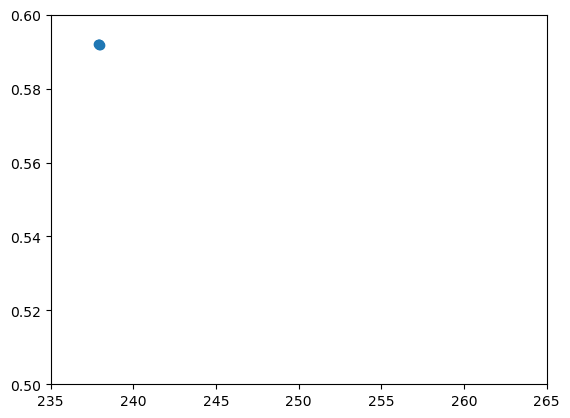

In [123]:
fig, ax  = plt.subplots()

ax.scatter(df_results['res'], df_results['r2_all'])
ax.set_ylim(0.5, 0.6)
ax.set_xlim(235, 265)
plt.show()

In [124]:
df_results.write_csv(os.path.join('outputs', 'post_deap_multi_optimise_coeffs_results.csv'))

## annealing

In [199]:
coeffs_init_start2 = {}
# i = 0
# for k, v in coeffs_init_start.items():
#     if i > 4:
#         coeffs_init_start2[k] = v
#     i += 1
# i = 0
for k, v in coeffs_init_start.items():
    if k in list(dict_coeffs.keys()):
        pass
    else:
        coeffs_init_start2[k] = v
coeffs_init_start = coeffs_init_start2

In [172]:
dict_coeffs.keys()

dict_keys(['randomseed04', 'randomseed41', 'randomseed47', 'randomseed65', 'randomseed81', 'randomseed05', 'randomseed06', 'randomseed07', 'randomseed08', 'randomseed09', 'randomseed10', 'randomseed11', 'randomseed12', 'randomseed13', 'randomseed14', 'randomseed15', 'randomseed16', 'randomseed17', 'randomseed18', 'randomseed19'])

In [174]:
sorted(list(coeffs_init_start2.keys()))

['randomseed20',
 'randomseed21',
 'randomseed22',
 'randomseed23',
 'randomseed24',
 'randomseed25',
 'randomseed26',
 'randomseed27',
 'randomseed28',
 'randomseed29',
 'randomseed30',
 'randomseed31',
 'randomseed32',
 'randomseed33',
 'randomseed34',
 'randomseed35',
 'randomseed36',
 'randomseed37',
 'randomseed38',
 'randomseed39',
 'randomseed40',
 'randomseed42',
 'randomseed43',
 'randomseed44',
 'randomseed45',
 'randomseed46',
 'randomseed48',
 'randomseed49',
 'randomseed50',
 'randomseed51',
 'randomseed52',
 'randomseed53',
 'randomseed54',
 'randomseed55',
 'randomseed56',
 'randomseed57',
 'randomseed58',
 'randomseed59',
 'randomseed60',
 'randomseed61',
 'randomseed62',
 'randomseed63',
 'randomseed64',
 'randomseed66',
 'randomseed67',
 'randomseed68',
 'randomseed69',
 'randomseed70',
 'randomseed71',
 'randomseed72',
 'randomseed73',
 'randomseed74',
 'randomseed75',
 'randomseed76',
 'randomseed77',
 'randomseed78',
 'randomseed79',
 'randomseed80',
 'randomseed82

In [200]:
# dict_coeffs = {}
# dict_opt_results = {}
# Store these opt results keys:
opt_results_keys = ['success', 'nit', 'minimization_failures', 'nfev']  # basin-hopping

i = 1
for coeff_combo, coeffs_init in coeffs_init_start.items():
    print(f'{i:5d} out of {len(coeffs_init_start)}', end='\r')
    i += 1
    bounds_here = [(0.0, 1.0)] * len(coeffs_init)  # force results to lie between 0 and 1
    
    
    # Run the optimiser:
    opt_results = basinhopping(
        main_opt,
        x0=coeffs_init,
        T=30.0,  # experiment
        stepsize=5e-5,
        minimizer_kwargs = dict(
            args=[all_x_lists, all_admissions, admissions_by_age],
            # bounds=[(0.0, 1.0)] * len(age_coeffs),  # force results to lie between 0 and 1
            bounds=bounds_here,
            method='Nelder-Mead',
            options=dict(maxiter=10000),
            ),
    )
    # Pick out the resulting health coefficients:
    coeffs = np.round(opt_results['x'], 7)

    # Calculate R^2 here:

    # Log whether this combo optimised successfully:
    opt_results_to_save = [opt_results['message'][0]] + [opt_results[k] for k in opt_results_keys]
    # Log whether this combo optimised successfully:
    dict_opt_results[coeff_combo] = pl.DataFrame(np.array([[f'{coeff_combo}'] + opt_results_to_save]), schema=['coeff_combo', 'message'] + opt_results_keys)  # basin-hopping
    # pl.Series(f'{coeff_combo}', [opt_results[k] for k in opt_results_keys], strict=False).to_frame()
    # Store coeffs:
    dict_coeffs[coeff_combo] = pl.DataFrame(np.array([[f'{coeff_combo}'] + list(coeffs)]), schema=['coeff_combo'] + coeff_names)
    # pl.Series(f'{coeff_combo}', coeffs).to_frame()

Gather results into dataFrames:

In [201]:
df_ann_opt_results = pl.concat(dict_opt_results.values())

# df_opt_results = df_opt_results.with_columns(pl.Series('coeff_combo', df_opt_results['coeff_combo'].cast(int)))

In [202]:
df_ann_opt_results

coeff_combo,message,success,nit,minimization_failures,nfev
str,str,str,str,str,str
"""randomseed04""","""requested number of basinhoppi…","""True""","""100""","""0""","""114740"""
"""randomseed41""","""requested number of basinhoppi…","""True""","""100""","""0""","""113365"""
"""randomseed47""","""requested number of basinhoppi…","""True""","""100""","""0""","""113848"""
"""randomseed65""","""requested number of basinhoppi…","""True""","""100""","""0""","""111889"""
"""randomseed81""","""requested number of basinhoppi…","""True""","""100""","""0""","""113269"""
…,…,…,…,…,…
"""randomseed95""","""requested number of basinhoppi…","""True""","""100""","""0""","""112269"""
"""randomseed96""","""requested number of basinhoppi…","""True""","""100""","""0""","""107083"""
"""randomseed97""","""requested number of basinhoppi…","""True""","""100""","""0""","""113504"""


In [203]:
df_ann_coeffs = pl.concat(dict_coeffs.values())#.cast(float)

# df_coeffs = df_coeffs.with_columns(pl.Series('coeff_combo', df_coeffs['coeff_combo'].cast(int)))
for c in coeff_names:
    df_ann_coeffs = df_ann_coeffs.with_columns(pl.Series(c, df_ann_coeffs[c].cast(float)))

In [204]:
df_ann_coeffs

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.0005827,0.0043462,0.0047695,0.0076783,0.0130495,0.000512,0.002964,0.0042242,0.0067299,0.0125452,0.0003838,0.002716,0.0039933,0.0062825,0.0123945,0.0003612,0.0022613,0.0034521,0.0058162,0.0117019,0.0003099,0.0021174,0.0033669,0.0047795,0.0112252
"""randomseed41""",0.0006155,0.0034183,0.0048369,0.0092577,0.0129556,0.0004996,0.0032402,0.0044726,0.0064515,0.0126364,0.000381,0.0028137,0.0039393,0.0056569,0.0122359,0.0003611,0.0024693,0.0034302,0.0053334,0.0117318,0.0002893,0.0022714,0.0032093,0.0050857,0.0113229
"""randomseed47""",0.0005963,0.0036286,0.0045918,0.0084446,0.0137422,0.0005401,0.003466,0.0043459,0.0061543,0.0123531,0.0004047,0.0027263,0.0039866,0.0058866,0.0118604,0.000337,0.0024766,0.0036223,0.0054936,0.0115865,0.0002659,0.002001,0.0032216,0.005419,0.0115295
"""randomseed65""",0.0005981,0.0045716,0.0056902,0.0064468,0.0134018,0.0004845,0.0032214,0.0044455,0.0063832,0.0123534,0.0004184,0.0026293,0.0038337,0.006124,0.0119998,0.0003292,0.0025889,0.0036859,0.0059045,0.0116559,0.0003186,0.0014798,0.0025383,0.0058138,0.0115409
"""randomseed81""",0.0006573,0.0034361,0.004442,0.0068929,0.0130648,0.0005155,0.0031248,0.0041468,0.0064678,0.0124398,0.0003604,0.0028793,0.003966,0.0062715,0.0121439,0.0003244,0.002668,0.0036147,0.0058001,0.0117746,0.0002822,0.0020879,0.0034913,0.0054603,0.0114378
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed95""",0.0006105,0.0039282,0.0050174,0.0076273,0.0130249,0.0005219,0.0027405,0.0045816,0.0070862,0.0123435,0.0003904,0.0026548,0.0040108,0.005788,0.0121354,0.0003769,0.0024979,0.0033019,0.0054829,0.0116925,0.0002449,0.0024349,0.0030779,0.0053215,0.0116155
"""randomseed96""",0.0005964,0.0038698,0.0050454,0.007007,0.0138797,0.0005289,0.003053,0.0042193,0.0065794,0.0124512,0.0003787,0.0028317,0.0037605,0.0062334,0.01203,0.000352,0.0023668,0.003716,0.0056799,0.0115767,0.0002902,0.0021788,0.0031473,0.0054646,0.0112428
"""randomseed97""",0.0005476,0.0034344,0.005,0.0073999,0.0149065,0.000494,0.0030188,0.0041674,0.0069273,0.0126168,0.0004082,0.0027732,0.0037524,0.0061595,0.011835,0.0003894,0.0024835,0.0035512,0.005636,0.011566,0.0003163,0.0024704,0.0033873,0.0050883,0.0107054


In [205]:
df_coeffs_init

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.000597,0.004482,0.004503,0.007166,0.013902,0.000486,0.003129,0.004482,0.007166,0.012731,0.000392,0.002639,0.003735,0.006005,0.012492,0.000347,0.002114,0.003639,0.005995,0.011558,0.00033,0.002099,0.003361,0.004804,0.010753
"""randomseed41""",0.0005712,0.003687,0.00557,0.007206,0.013597,0.000512,0.003102,0.004036,0.006306,0.013006,0.000408,0.002785,0.003735,0.006005,0.011558,0.0003264,0.002542,0.003735,0.006005,0.011558,0.0003264,0.002115,0.002988,0.005458,0.011352
"""randomseed47""",0.000616,0.003407,0.004956,0.008039,0.01387,0.000454,0.003168,0.004482,0.006757,0.012985,0.000405,0.0028,0.003735,0.006103,0.011558,0.000368,0.00245,0.003508,0.005757,0.011426,0.000308,0.002352,0.003225,0.004918,0.011426
"""randomseed65""",0.000565,0.004515,0.005976,0.006535,0.013649,0.000491,0.003125,0.004482,0.006535,0.012831,0.000403,0.002644,0.003735,0.006005,0.011781,0.000372,0.00261,0.00361,0.00583,0.011451,0.000323,0.0015864,0.002607,0.005822,0.01135
"""randomseed81""",0.000602,0.003702,0.005229,0.006653,0.01387,0.000452,0.0031728,0.004419,0.006653,0.013686,0.000406,0.002644,0.003735,0.006005,0.011866,0.000366,0.002577,0.00371,0.006005,0.010991,0.000326,0.002091,0.002988,0.005577,0.010991


Check result:

In [206]:
qmin_list = np.round(qmin_list, 1)

In [207]:
list_r2_dicts = []

for coeff_combo in df_ann_coeffs['coeff_combo']:
    dict_r2 = {}
    mask = df_ann_coeffs['coeff_combo'] == coeff_combo
    row_coeffs = df_ann_coeffs.filter(mask)

    df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))
    
    for q in qmin_list:
        qstr = str(round(q, 1)).replace('.', '')
        df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)
        
        for a in age_numbers:
            df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (row_coeffs[f'{a}_q{qstr}'].to_numpy()[0] * df_here[a])))

        # R2 for just this q:
        r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
        dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)
        
        mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])

        # df_admissions_here = df_admissions_here.with_columns(
        #    pl.when(mask)
        #      .then(df_here['admissions_predicted'])
        #      .otherwise(pl.col('admissions_predicted'))
        #      .name.keep()
        # )
        df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
        
    cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))
    
    # Calculate R2:
    r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
    dict_r2['r2_all'] = np.round(r2, 5)
    # Calculate residuals:
    res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
    dict_r2['res'] = np.round(res, 3)
            

    list_r2_dicts.append(pl.DataFrame([[coeff_combo] + list(dict_r2.values())], schema=['coeff_combo'] + list(dict_r2.keys())))

In [208]:
# Convert results to dataframe:
df_ann_r2 = pl.concat(list_r2_dicts, how='vertical')

In [209]:
df_ann_r2

coeff_combo,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.49476,0.58242,0.6363,0.60875,0.61996,0.59272,237.678
"""randomseed41""",0.49383,0.5818,0.63753,0.60858,0.6209,0.59285,237.64
"""randomseed47""",0.49494,0.58106,0.63682,0.60705,0.62177,0.5926,237.713
"""randomseed65""",0.49478,0.58013,0.63724,0.60677,0.62021,0.59212,237.852
"""randomseed81""",0.4947,0.58238,0.63687,0.60698,0.62018,0.59251,237.738
…,…,…,…,…,…,…,…
"""randomseed95""",0.49609,0.58138,0.63748,0.60883,0.62199,0.59342,237.474
"""randomseed96""",0.49638,0.58254,0.63709,0.60787,0.62078,0.59319,237.541
"""randomseed97""",0.49291,0.58172,0.63696,0.60637,0.61774,0.59149,238.036


In [210]:
df_ann_r2.sort('res')

coeff_combo,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,f64,f64,f64,f64,f64,f64,f64
"""randomseed15""",0.49603,0.58189,0.63766,0.60951,0.62133,0.59356,237.433
"""randomseed95""",0.49609,0.58138,0.63748,0.60883,0.62199,0.59342,237.474
"""randomseed31""",0.49668,0.58252,0.63663,0.60748,0.62222,0.59334,237.498
"""randomseed53""",0.49665,0.58177,0.63754,0.60824,0.62116,0.59333,237.5
"""randomseed77""",0.49657,0.58285,0.63631,0.60745,0.62167,0.5932,237.538
…,…,…,…,…,…,…,…
"""randomseed18""",0.49292,0.58157,0.63774,0.60743,0.61642,0.59159,238.006
"""randomseed74""",0.49417,0.57953,0.63631,0.60788,0.61857,0.59159,238.006
"""randomseed97""",0.49291,0.58172,0.63696,0.60637,0.61774,0.59149,238.036


Merge R2 results into main optimisation results:

In [211]:
df_ann_opt_results = df_ann_opt_results.join(df_ann_r2, on='coeff_combo', how='left')

In [212]:
df_ann_opt_results

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""","""requested number of basinhoppi…","""True""","""100""","""0""","""114740""",0.49476,0.58242,0.6363,0.60875,0.61996,0.59272,237.678
"""randomseed41""","""requested number of basinhoppi…","""True""","""100""","""0""","""113365""",0.49383,0.5818,0.63753,0.60858,0.6209,0.59285,237.64
"""randomseed47""","""requested number of basinhoppi…","""True""","""100""","""0""","""113848""",0.49494,0.58106,0.63682,0.60705,0.62177,0.5926,237.713
"""randomseed65""","""requested number of basinhoppi…","""True""","""100""","""0""","""111889""",0.49478,0.58013,0.63724,0.60677,0.62021,0.59212,237.852
"""randomseed81""","""requested number of basinhoppi…","""True""","""100""","""0""","""113269""",0.4947,0.58238,0.63687,0.60698,0.62018,0.59251,237.738
…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed95""","""requested number of basinhoppi…","""True""","""100""","""0""","""112269""",0.49609,0.58138,0.63748,0.60883,0.62199,0.59342,237.474
"""randomseed96""","""requested number of basinhoppi…","""True""","""100""","""0""","""107083""",0.49638,0.58254,0.63709,0.60787,0.62078,0.59319,237.541
"""randomseed97""","""requested number of basinhoppi…","""True""","""100""","""0""","""113504""",0.49291,0.58172,0.63696,0.60637,0.61774,0.59149,238.036


In [213]:
df_ann_results = df_ann_opt_results.join(df_ann_coeffs, on='coeff_combo', how='left')

In [214]:
df_ann_results.sort('r2_all', descending=True)

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed15""","""requested number of basinhoppi…","""True""","""100""","""0""","""109665""",0.49603,0.58189,0.63766,0.60951,0.62133,0.59356,237.433,0.0006294,0.00339,0.006573,0.0069397,0.0121848,0.000523,0.0032394,0.0046271,0.0063534,0.0121827,0.0004,0.0030352,0.0034647,0.0062635,0.0121326,0.0003611,0.0026149,0.002969,0.0056608,0.0119939,0.0002279,0.0019295,0.0029079,0.0056607,0.0119332
"""randomseed95""","""requested number of basinhoppi…","""True""","""100""","""0""","""112269""",0.49609,0.58138,0.63748,0.60883,0.62199,0.59342,237.474,0.0006105,0.0039282,0.0050174,0.0076273,0.0130249,0.0005219,0.0027405,0.0045816,0.0070862,0.0123435,0.0003904,0.0026548,0.0040108,0.005788,0.0121354,0.0003769,0.0024979,0.0033019,0.0054829,0.0116925,0.0002449,0.0024349,0.0030779,0.0053215,0.0116155
"""randomseed31""","""requested number of basinhoppi…","""True""","""100""","""0""","""111991""",0.49668,0.58252,0.63663,0.60748,0.62222,0.59334,237.498,0.0006504,0.0035075,0.0050357,0.0069418,0.013036,0.0005251,0.0032405,0.0043631,0.0062476,0.0123882,0.000367,0.003054,0.0038563,0.0061388,0.0119904,0.0003279,0.0025737,0.0035384,0.0058777,0.0117954,0.0002691,0.0018647,0.0031354,0.0056335,0.0116037
"""randomseed53""","""requested number of basinhoppi…","""True""","""100""","""0""","""113104""",0.49665,0.58177,0.63754,0.60824,0.62116,0.59333,237.5,0.0006287,0.0044088,0.0045837,0.0071455,0.0128388,0.0004931,0.0031293,0.0042775,0.0067528,0.0127514,0.0004009,0.0025444,0.0039706,0.0061818,0.0121444,0.0003396,0.0022534,0.0034906,0.0060611,0.0117106,0.0002821,0.0021056,0.0034248,0.004925,0.011408
"""randomseed77""","""requested number of basinhoppi…","""True""","""100""","""0""","""116813""",0.49657,0.58285,0.63631,0.60745,0.62167,0.5932,237.538,0.0006308,0.0033924,0.0046398,0.0074256,0.0137218,0.0005269,0.0033085,0.0039687,0.0060948,0.0125377,0.0003843,0.003229,0.0039076,0.0060053,0.0118253,0.0003347,0.0023853,0.0036133,0.0059816,0.0115462,0.0002646,0.0019175,0.003557,0.0054752,0.0114786
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed18""","""requested number of basinhoppi…","""True""","""100""","""0""","""118480""",0.49292,0.58157,0.63774,0.60743,0.61642,0.59159,238.006,0.000579,0.0030535,0.0051298,0.0084107,0.0144879,0.0005134,0.0029051,0.0045666,0.007035,0.0122385,0.0004133,0.0028881,0.0037305,0.0057218,0.0122332,0.0003888,0.0027358,0.0033993,0.0053914,0.0112985,0.0002544,0.002481,0.0031777,0.0050455,0.0111306
"""randomseed74""","""requested number of basinhoppi…","""True""","""100""","""0""","""114806""",0.49417,0.57953,0.63631,0.60788,0.61857,0.59159,238.006,0.0005871,0.0036832,0.0051967,0.0081662,0.0136541,0.0004711,0.0031009,0.0045537,0.0068565,0.0130652,0.000385,0.0027624,0.0037454,0.0063289,0.0118422,0.0003664,0.0025586,0.0035581,0.0054695,0.011482,0.0003435,0.0021484,0.0029734,0.0047009,0.0111888
"""randomseed97""","""requested number of basinhoppi…","""True""","""100""","""0""","""113504""",0.49291,0.58172,0.63696,0.60637,0.61774,0.59149,238.036,0.0005476,0.0034344,0.005,0.0073999,0.0149065,0.000494,0.0030188,0.0041674,0.0069273,0.0126168,0.0004082,0.0027732,0.0037524,0.0061595,0.011835,0.0003894,0.0024835,0.0035512,0.005636,0.011566,0.0003163,0.0024704,0.0033873,0.0050883,0.0107054


In [215]:
pl.concat((df_ann_results.min(), df_ann_results.max()))

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""","""requested number of basinhoppi…","""True""","""100""","""0""","""107083""",0.49015,0.57849,0.63517,0.60502,0.61537,0.5912,237.433,0.0005323,0.0030173,0.0042074,0.0064468,0.0121848,0.0004684,0.0027405,0.0037828,0.006043,0.011954,0.0003502,0.002336,0.0033775,0.0054988,0.0117412,0.0003026,0.0020367,0.002969,0.0051069,0.0109337,0.0002033,0.0014798,0.0025383,0.0045157,0.0106843
"""randomseed99""","""requested number of basinhoppi…","""True""","""100""","""0""","""121172""",0.49693,0.58309,0.63838,0.60951,0.62232,0.59356,238.121,0.0006755,0.0045716,0.006573,0.0092577,0.0149065,0.0005793,0.0037662,0.0048588,0.0076715,0.0133362,0.000452,0.003229,0.0040732,0.0066265,0.0124641,0.0004083,0.0028183,0.0038132,0.0060611,0.0119939,0.0003435,0.0026063,0.0036399,0.0058138,0.0119332


In [229]:
mask = np.round(df_ann_results['r2_all'], 3) == np.round(df_ann_results['r2_all'].max(), 3)

df_best_ann = df_ann_results.filter(mask)[coeff_names]

In [228]:
df_range = df_ann_results.max()[coeff_names] - df_ann_results.min()[coeff_names]

In [240]:
df = pl.concat((df_ann_results.min()[coeff_names], df_ann_results.max()[coeff_names], df_range, df_best_ann))

for col in coeff_names:
    if 'less65' in col:
        n = 5
    elif 'over80' in col:
        n = 3
    else:
        n = 4
    df = df.with_columns(pl.col(col).round(n))

df

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.00053,0.003,0.0042,0.0064,0.012,0.00047,0.0027,0.0038,0.006,0.012,0.00035,0.0023,0.0034,0.0055,0.012,0.0003,0.002,0.003,0.0051,0.011,0.0002,0.0015,0.0025,0.0045,0.011
0.00068,0.0046,0.0066,0.0093,0.015,0.00058,0.0038,0.0049,0.0077,0.013,0.00045,0.0032,0.0041,0.0066,0.012,0.00041,0.0028,0.0038,0.0061,0.012,0.00034,0.0026,0.0036,0.0058,0.012
0.00014,0.0016,0.0024,0.0028,0.003,0.00011,0.001,0.0011,0.0016,0.001,0.0001,0.0009,0.0007,0.0011,0.001,0.00011,0.0008,0.0008,0.001,0.001,0.00014,0.0011,0.0011,0.0013,0.001
0.00063,0.0034,0.0066,0.0069,0.012,0.00052,0.0032,0.0046,0.0064,0.012,0.0004,0.003,0.0035,0.0063,0.012,0.00036,0.0026,0.003,0.0057,0.012,0.00023,0.0019,0.0029,0.0057,0.012


In [244]:
df = pl.concat((df_ann_results.min()[coeff_names], df_ann_results.max()[coeff_names], df_range, df_best_ann))

for col in coeff_names:
    if 'less65' in col:
        n = 4
    elif 'over80' in col:
        n = 3
    else:
        n = 3
    df = df.with_columns(pl.col(col).round(n))

df * 100.0

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.05,0.3,0.4,0.6,1.2,0.05,0.3,0.4,0.6,1.2,0.04,0.2,0.3,0.5,1.2,0.03,0.2,0.3,0.5,1.1,0.02,0.1,0.3,0.5,1.1
0.07,0.5,0.7,0.9,1.5,0.06,0.4,0.5,0.8,1.3,0.05,0.3,0.4,0.7,1.2,0.04,0.3,0.4,0.6,1.2,0.03,0.3,0.4,0.6,1.2
0.01,0.2,0.2,0.3,0.3,0.01,0.1,0.1,0.2,0.1,0.01,0.1,0.1,0.1,0.1,0.01,0.1,0.1,0.1,0.1,0.01,0.1,0.1,0.1,0.1
0.06,0.3,0.7,0.7,1.2,0.05,0.3,0.5,0.6,1.2,0.04,0.3,0.3,0.6,1.2,0.04,0.3,0.3,0.6,1.2,0.02,0.2,0.3,0.6,1.2


In [246]:
df = df_best_ann

for col in coeff_names:
    if 'less65' in col:
        n = 4
    elif 'over80' in col:
        n = 3
    else:
        n = 3
    df = df.with_columns(pl.col(col).round(n))

(df * 100.0).to_numpy().reshape(5, 5)

array([[0.06, 0.3 , 0.7 , 0.7 , 1.2 ],
       [0.05, 0.3 , 0.5 , 0.6 , 1.2 ],
       [0.04, 0.3 , 0.3 , 0.6 , 1.2 ],
       [0.04, 0.3 , 0.3 , 0.6 , 1.2 ],
       [0.02, 0.2 , 0.3 , 0.6 , 1.2 ]])

In [232]:
df_range

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0001432,0.001554,0.0023656,0.002811,0.002722,0.000111,0.0010257,0.001076,0.001629,0.0013822,0.000102,0.000893,0.0006957,0.001128,0.000723,0.000106,0.000782,0.000844,0.000954,0.00106,0.0001402,0.001127,0.001102,0.0012981,0.001249


In [233]:
df_best_ann

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0006294,0.00339,0.006573,0.0069397,0.0121848,0.000523,0.0032394,0.0046271,0.0063534,0.0121827,0.0004,0.0030352,0.0034647,0.0062635,0.0121326,0.0003611,0.0026149,0.002969,0.0056608,0.0119939,0.0002279,0.0019295,0.0029079,0.0056607,0.0119332


In [231]:
100.0 * df_range / df_best_ann

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
22.751827,45.849558,35.989655,40.504633,22.336846,21.204589,31.663271,23.254306,25.631945,11.345597,25.45,29.421455,20.079661,18.004311,5.958327,29.27167,29.890244,28.433816,16.856275,8.839493,61.51821,58.383001,37.883008,22.931793,10.465759


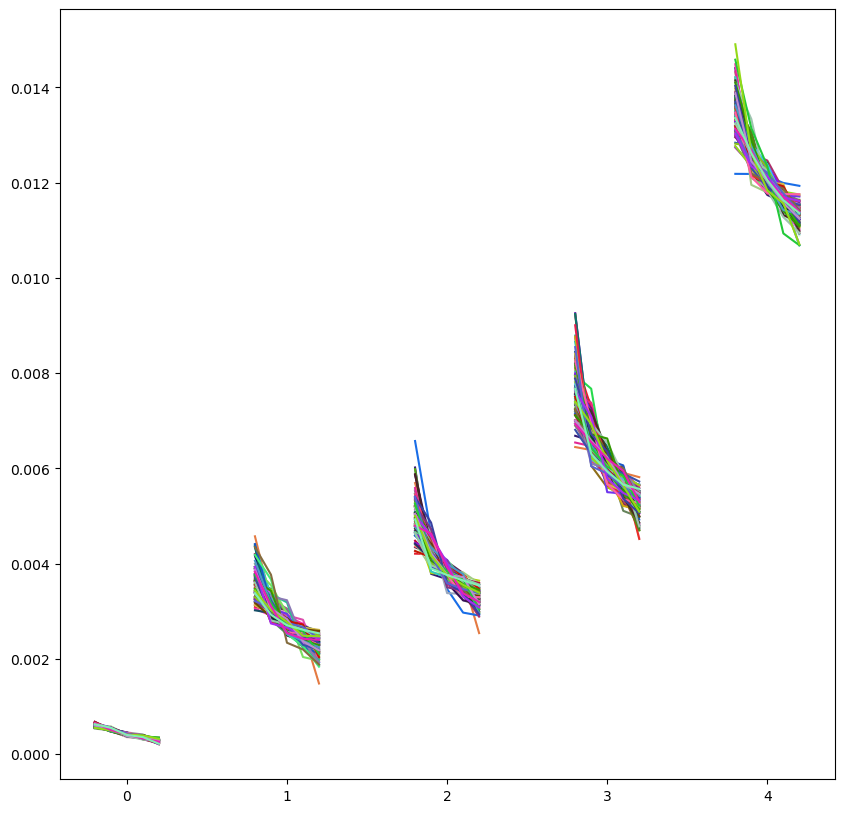

In [216]:
fig, ax = plt.subplots(figsize=(10, 10))

# colours = ['b', 'r']
# labels = ['DEAP', 'DEAP then anneal']

for results_dir in df_ann_results['coeff_combo']:
    # Pick out coeffs:
    # coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    coeffs_ann = df_ann_results.filter(df_ann_results['coeff_combo'] == results_dir)[coeff_names].to_numpy().flatten() / np.concatenate([coeffs_ssnap] * 5)
    # for i, coeffs in enumerate([coeffs, coeffs_ann]):
    for i, coeffs in enumerate([coeffs_ann]):
        # if results_dir in df_best_gens_topr2['dir']:
        colour = np.random.rand(3,)
        # colour = colours[i]
        zorder = 5
        alpha = 1.0
        # else:
        #     colour = 'silver'
        #     zorder = 4
        #     alpha = 0.4
        # g = gen_attr(df_coeffs_init)
    
        offset = -0.2
        for c in range(5):
            # xs = np.arange(5) + offset
            # ys = g[c*5:(c*5)+5]
            xs = np.arange(-0.2, 0.3, 0.1) + c
            
            ys = np.array(coeffs)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
            ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, 
                    # label=labels[i] if c < 1 else None)
                    label=(results_dir if c==0 else None))
            offset += 0.1
# ax.legend()

plt.show()

In [217]:
mask = np.round(df_best_gens['r2_all'], 3) == np.round(df_best_gens['r2_all'].max(), 3)

df_best_gens.filter(mask)

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",59.0,1.46312,1.695159,1.205551,1.19339,1.202789,1.19011,1.183463,1.2,1.19339,1.10153,0.960694,0.997975,1.0,1.0,1.080779,0.85047,0.799606,0.974258,0.998259,1.0,0.808107,0.793863,0.899786,0.8,0.930343,239.287371,0.59191,0.496018,0.579529,0.638646,0.607951,0.615709
"""randomseed41""",35.0,1.4,1.394472,1.491289,1.2,1.176441,1.253797,1.173068,1.080715,1.050118,1.125261,1.0,1.053346,1.0,1.0,1.0,0.8,0.961484,1.0,1.0,1.0,0.8,0.8,0.8,0.908886,0.982146,240.136292,0.591804,0.494457,0.58296,0.634319,0.606642,0.619415
"""randomseed47""",51.0,1.509935,1.288461,1.327035,1.33879,1.2,1.113402,1.198,1.2,1.125237,1.12347,0.992264,1.05886,1.0,1.016319,1.0,0.902984,0.926627,0.939284,0.958704,0.988581,0.755995,0.889544,0.863378,0.819027,0.988581,240.268793,0.591575,0.494178,0.579535,0.634652,0.607894,0.620379
"""randomseed65""",58.0,1.384298,1.707645,1.6,1.088252,1.180937,1.202216,1.18193,1.2,1.088252,1.110136,0.988208,1.0,1.0,1.0,1.019277,0.912351,0.987298,0.96661,0.970934,0.99073,0.79201,0.6,0.697933,0.969452,0.981982,240.477538,0.591558,0.494306,0.581535,0.635265,0.605752,0.619604
"""randomseed81""",30.0,1.474497,1.4,1.4,1.107886,1.2,1.106899,1.2,1.183136,1.107886,1.184099,0.995979,1.0,1.0,1.0,1.02665,0.89788,0.974566,0.993429,1.0,0.950901,0.799854,0.790744,0.8,0.928723,0.950901,241.679306,0.591511,0.496688,0.577989,0.636342,0.606189,0.619144


In [222]:
mask = np.round(df_ann_results['r2_all'], 3) == np.round(df_ann_results['r2_all'].max(), 3)

df_ann_results.filter(mask)

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed15""","""requested number of basinhoppi…","""True""","""100""","""0""","""109665""",0.49603,0.58189,0.63766,0.60951,0.62133,0.59356,237.433,0.0006294,0.00339,0.006573,0.0069397,0.0121848,0.000523,0.0032394,0.0046271,0.0063534,0.0121827,0.0004,0.0030352,0.0034647,0.0062635,0.0121326,0.0003611,0.0026149,0.002969,0.0056608,0.0119939,0.0002279,0.0019295,0.0029079,0.0056607,0.0119332


In [224]:
df_ann_results.sort('r2_all', descending=True)[:20]

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed15""","""requested number of basinhoppi…","""True""","""100""","""0""","""109665""",0.49603,0.58189,0.63766,0.60951,0.62133,0.59356,237.433,0.0006294,0.00339,0.006573,0.0069397,0.0121848,0.000523,0.0032394,0.0046271,0.0063534,0.0121827,0.0004,0.0030352,0.0034647,0.0062635,0.0121326,0.0003611,0.0026149,0.002969,0.0056608,0.0119939,0.0002279,0.0019295,0.0029079,0.0056607,0.0119332
"""randomseed95""","""requested number of basinhoppi…","""True""","""100""","""0""","""112269""",0.49609,0.58138,0.63748,0.60883,0.62199,0.59342,237.474,0.0006105,0.0039282,0.0050174,0.0076273,0.0130249,0.0005219,0.0027405,0.0045816,0.0070862,0.0123435,0.0003904,0.0026548,0.0040108,0.005788,0.0121354,0.0003769,0.0024979,0.0033019,0.0054829,0.0116925,0.0002449,0.0024349,0.0030779,0.0053215,0.0116155
"""randomseed31""","""requested number of basinhoppi…","""True""","""100""","""0""","""111991""",0.49668,0.58252,0.63663,0.60748,0.62222,0.59334,237.498,0.0006504,0.0035075,0.0050357,0.0069418,0.013036,0.0005251,0.0032405,0.0043631,0.0062476,0.0123882,0.000367,0.003054,0.0038563,0.0061388,0.0119904,0.0003279,0.0025737,0.0035384,0.0058777,0.0117954,0.0002691,0.0018647,0.0031354,0.0056335,0.0116037
"""randomseed53""","""requested number of basinhoppi…","""True""","""100""","""0""","""113104""",0.49665,0.58177,0.63754,0.60824,0.62116,0.59333,237.5,0.0006287,0.0044088,0.0045837,0.0071455,0.0128388,0.0004931,0.0031293,0.0042775,0.0067528,0.0127514,0.0004009,0.0025444,0.0039706,0.0061818,0.0121444,0.0003396,0.0022534,0.0034906,0.0060611,0.0117106,0.0002821,0.0021056,0.0034248,0.004925,0.011408
"""randomseed77""","""requested number of basinhoppi…","""True""","""100""","""0""","""116813""",0.49657,0.58285,0.63631,0.60745,0.62167,0.5932,237.538,0.0006308,0.0033924,0.0046398,0.0074256,0.0137218,0.0005269,0.0033085,0.0039687,0.0060948,0.0125377,0.0003843,0.003229,0.0039076,0.0060053,0.0118253,0.0003347,0.0023853,0.0036133,0.0059816,0.0115462,0.0002646,0.0019175,0.003557,0.0054752,0.0114786
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed06""","""requested number of basinhoppi…","""True""","""100""","""0""","""119537""",0.49592,0.58086,0.63698,0.60793,0.6222,0.59303,237.588,0.0006243,0.0034225,0.0051921,0.0078841,0.0130796,0.0004872,0.003216,0.004136,0.0073581,0.012555,0.0003897,0.0029982,0.0037883,0.0062009,0.0119381,0.0003593,0.0025368,0.0035616,0.0051069,0.0116522,0.0002856,0.0020408,0.0032479,0.0049756,0.0116417
"""randomseed21""","""requested number of basinhoppi…","""True""","""100""","""0""","""114573""",0.4944,0.58241,0.63678,0.6087,0.62143,0.59303,237.587,0.0005912,0.0035313,0.0054564,0.0083786,0.013165,0.0005195,0.0031084,0.0042293,0.0066784,0.0124134,0.0004263,0.0027184,0.0035578,0.0056412,0.0120031,0.0003735,0.0024601,0.0034111,0.0054441,0.0118187,0.0002355,0.0023995,0.0033749,0.0053441,0.0114774
"""randomseed46""","""requested number of basinhoppi…","""True""","""100""","""0""","""114996""",0.49666,0.58231,0.63706,0.60675,0.62114,0.59303,237.586,0.0006438,0.0030173,0.0050385,0.0071888,0.0135944,0.0005464,0.00296,0.0042839,0.0064571,0.0123701,0.0003679,0.0028196,0.0039494,0.0061467,0.0121241,0.0003299,0.0026886,0.0034129,0.0056806,0.0115498,0.0002502,0.0025767,0.0032338,0.005523,0.0114113


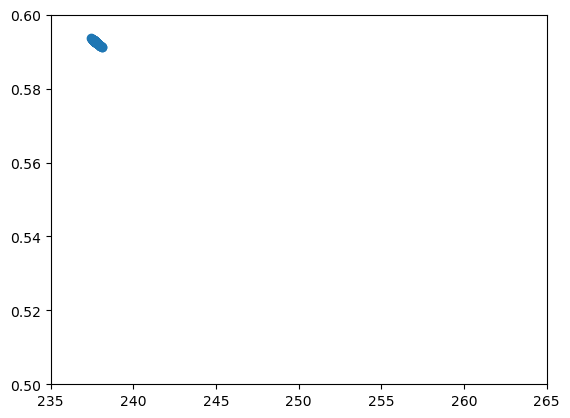

In [218]:
fig, ax  = plt.subplots()

ax.scatter(df_ann_results['res'], df_ann_results['r2_all'])
ax.set_ylim(0.5, 0.6)
ax.set_xlim(235, 265)
plt.show()

In [219]:
df_ann_results.write_csv(os.path.join('outputs', 'post_deap_multi_basinhop_coeffs_results.csv'))

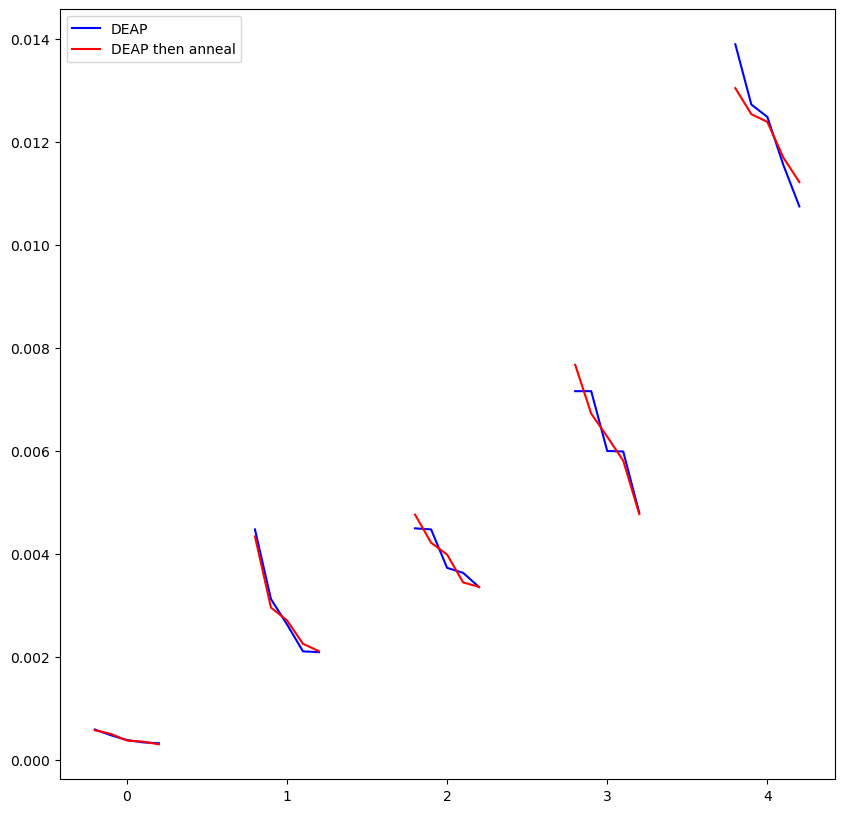

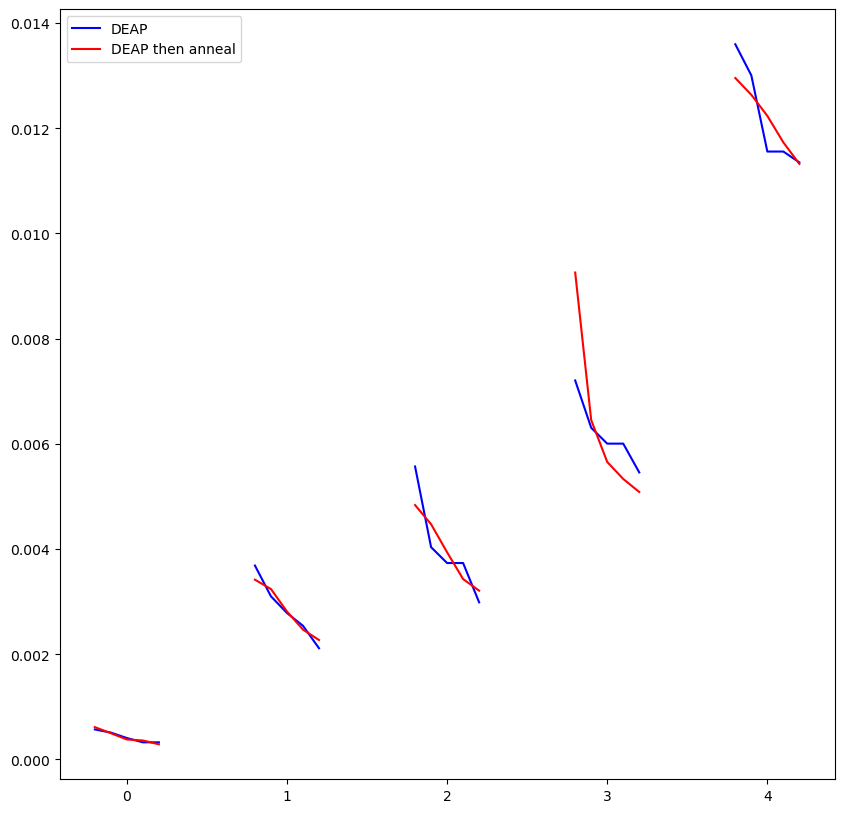

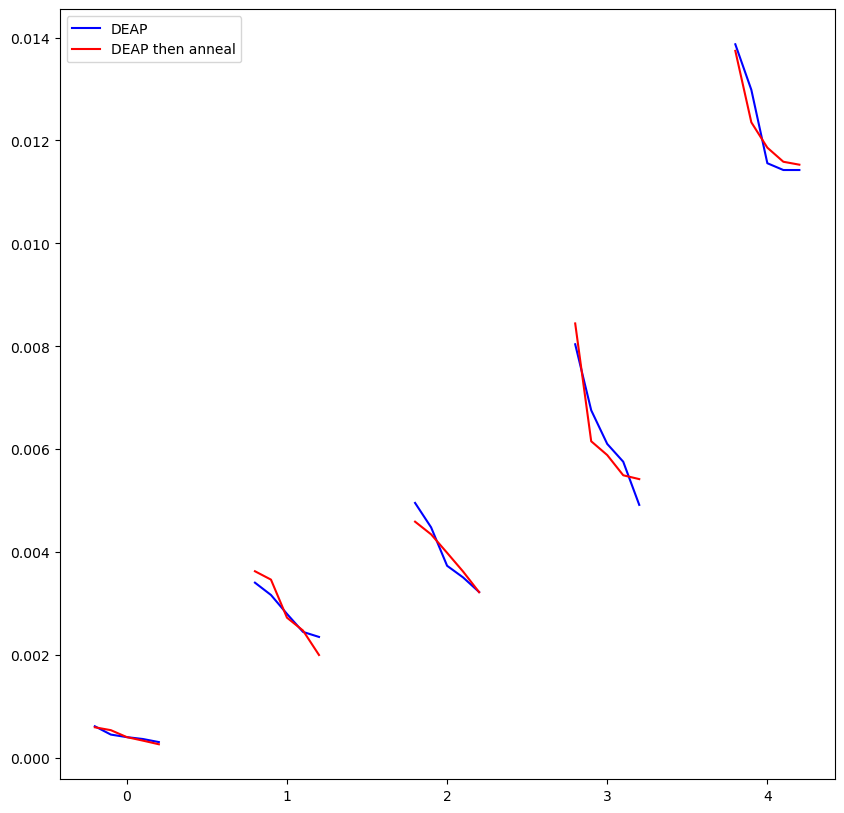

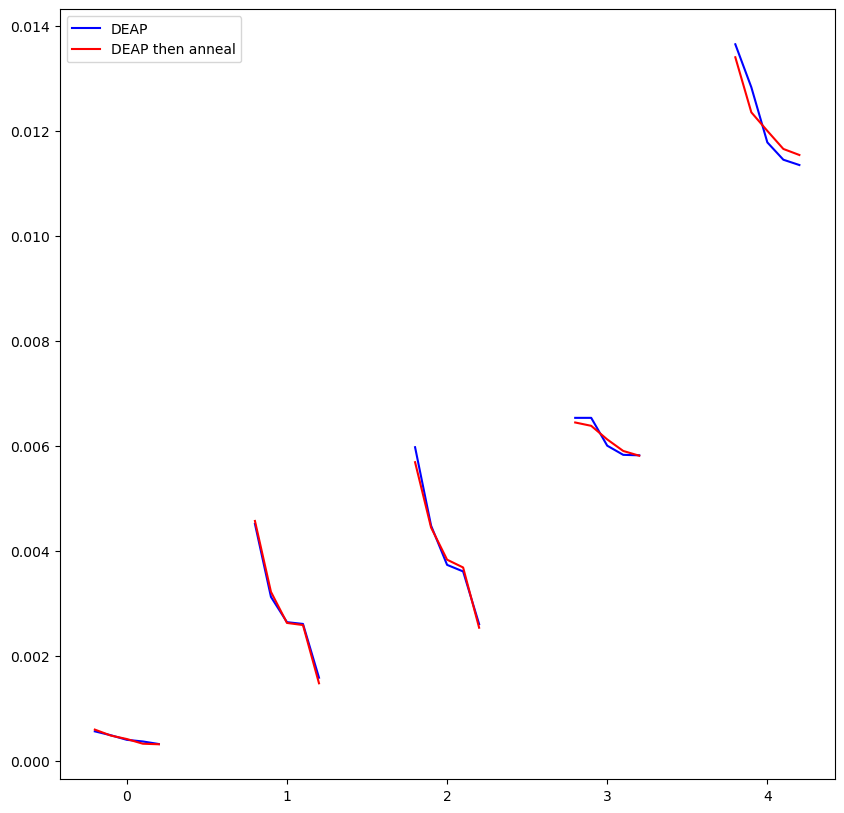

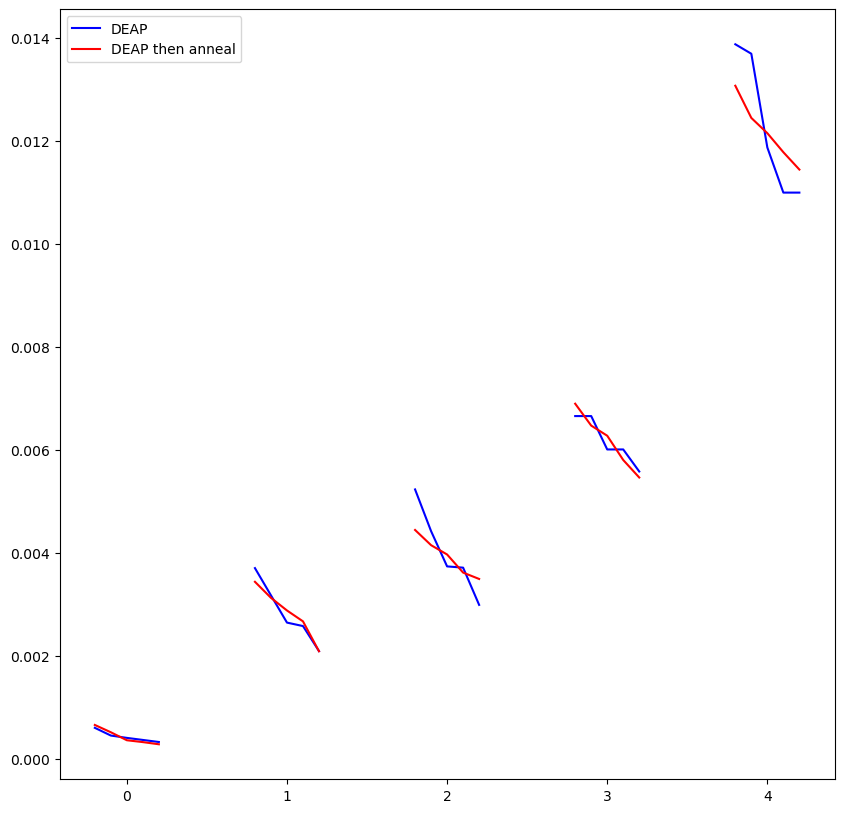

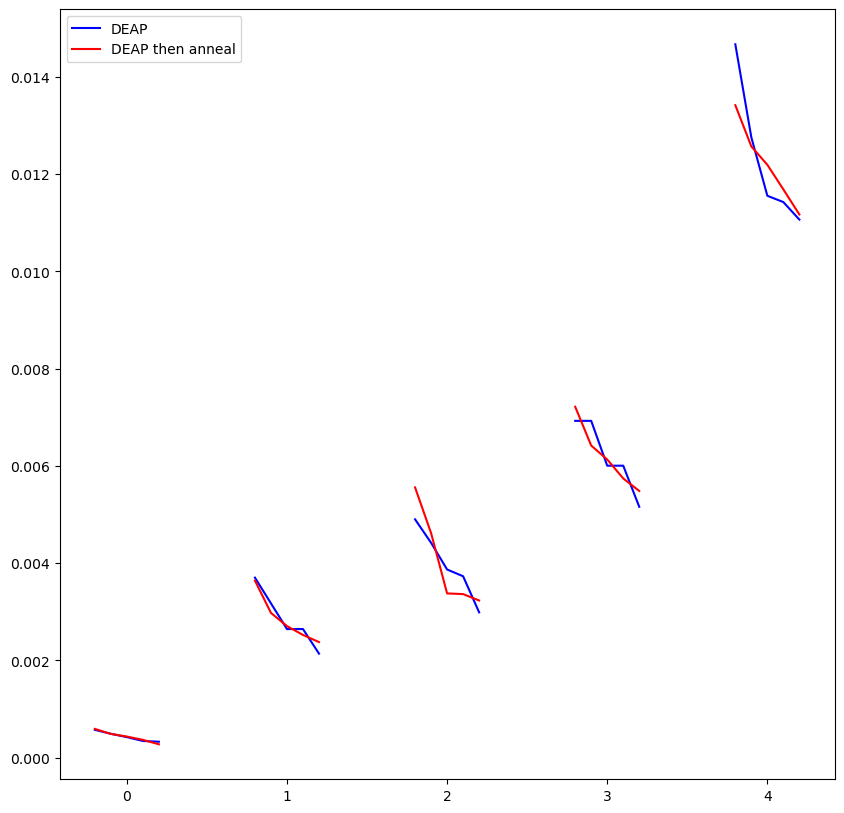

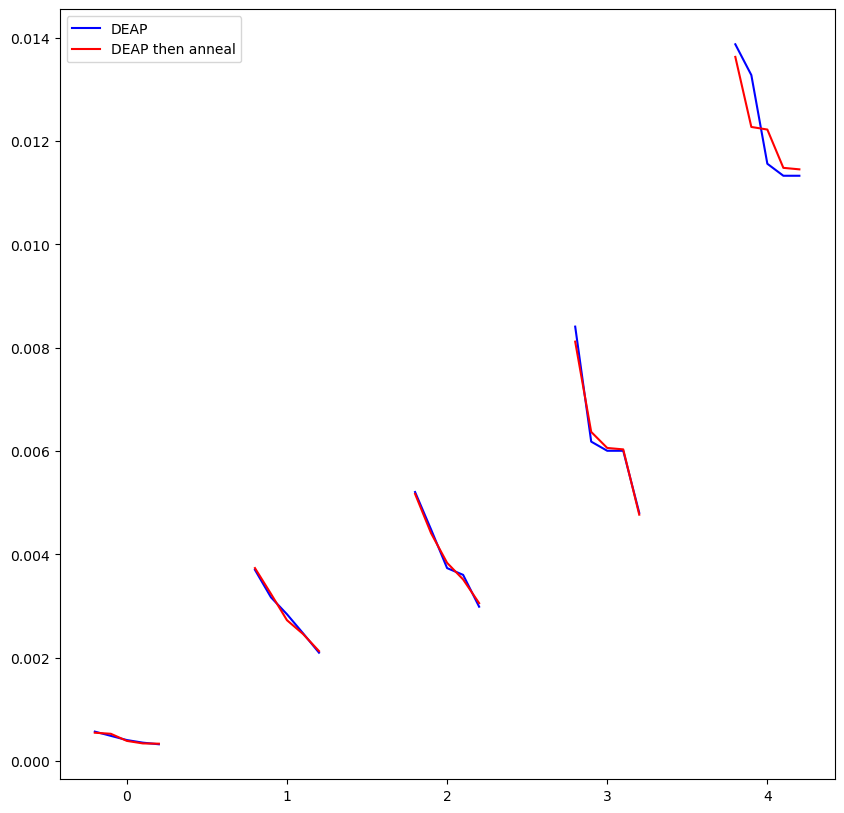

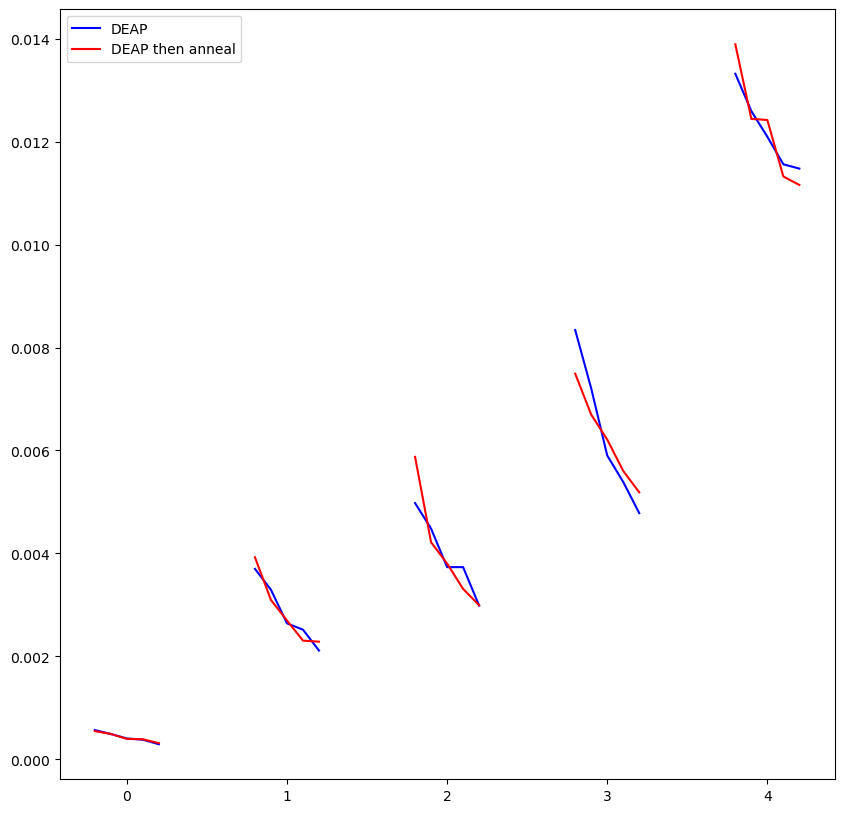

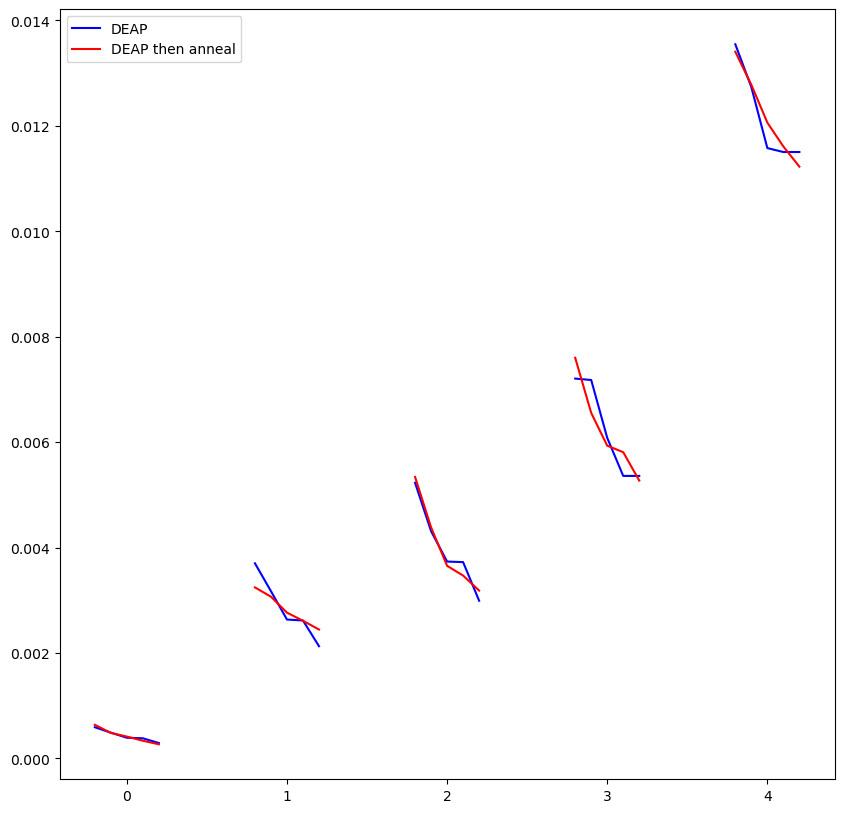

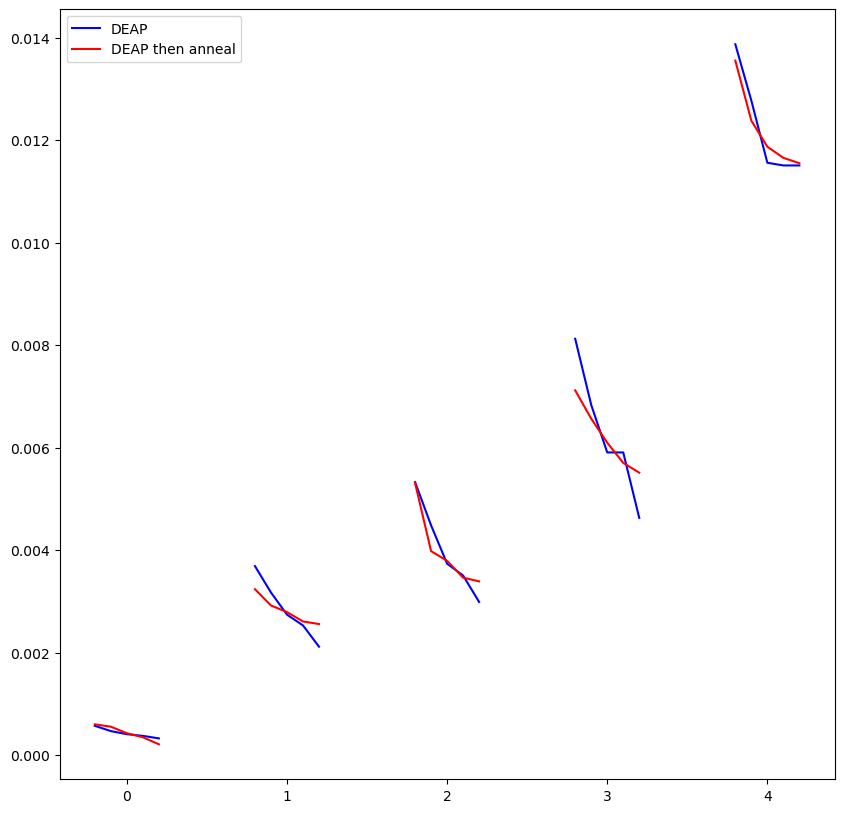

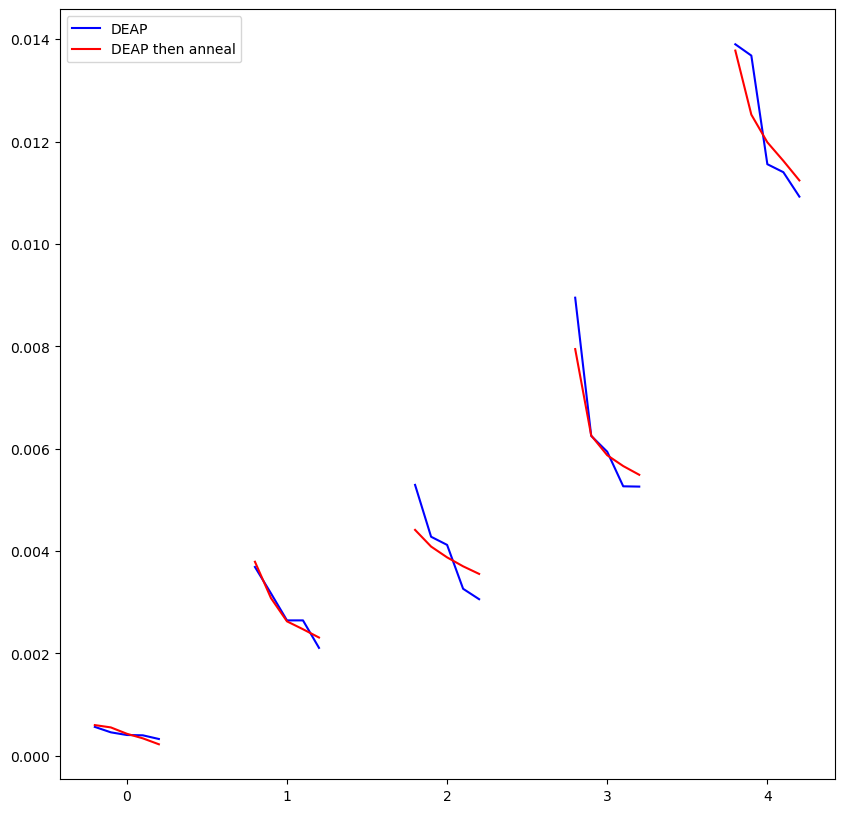

ValueError: operands could not be broadcast together with shapes (0,) (25,) 

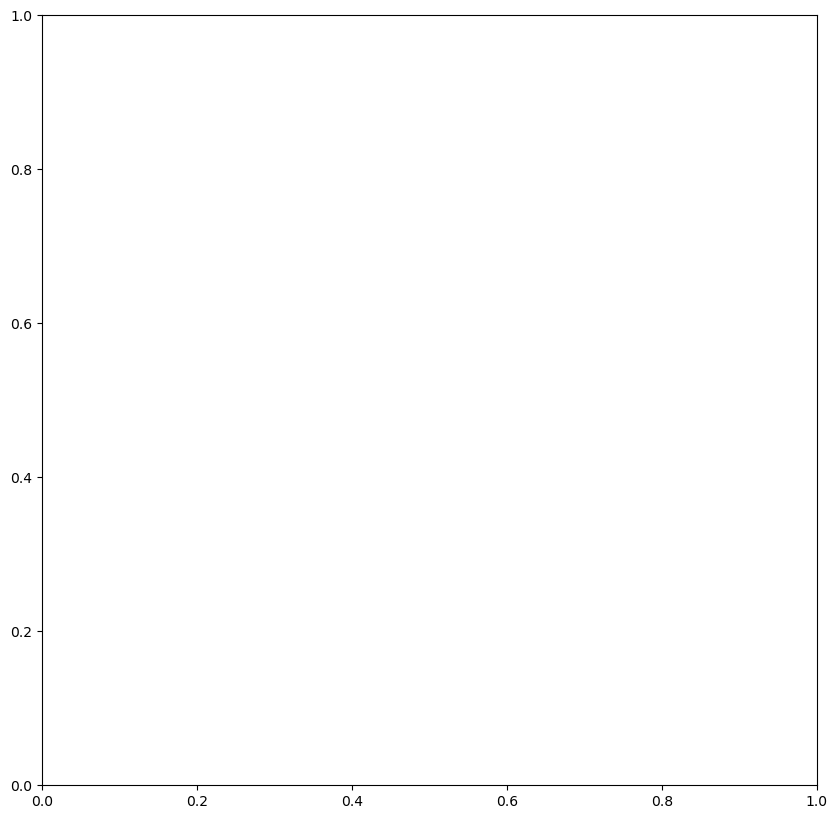

In [220]:
# fig, ax = plt.subplots(figsize=(10, 10))

colours = ['b', 'r']
labels = ['DEAP', 'DEAP then anneal']

for results_dir in best_dirs:
    fig, ax = plt.subplots(figsize=(10, 10))
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    coeffs_ann = df_ann_results.filter(df_ann_results['coeff_combo'] == results_dir)[coeff_names].to_numpy().flatten() / np.concatenate([coeffs_ssnap] * 5)
    for i, coeffs in enumerate([coeffs, coeffs_ann]):
        # if results_dir in df_best_gens_topr2['dir']:
        # colour = np.random.rand(3,)
        colour = colours[i]
        zorder = 5
        alpha = 1.0
        # else:
        #     colour = 'silver'
        #     zorder = 4
        #     alpha = 0.4
        # g = gen_attr(df_coeffs_init)
    
        offset = -0.2
        for c in range(5):
            # xs = np.arange(5) + offset
            # ys = g[c*5:(c*5)+5]
            xs = np.arange(-0.2, 0.3, 0.1) + c
            
            ys = np.array(coeffs)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
            ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, 
                    label=labels[i] if c < 1 else None)
                    # label=(results_dir if c==0 else None))
            offset += 0.1
    ax.legend()
    
    plt.show()

Plot admissions scatter for best coeffs:

In [247]:
coeff_combo = 'randomseed15'

mask = df_ann_coeffs['coeff_combo'] == coeff_combo
row_coeffs = df_ann_coeffs.filter(mask)

df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))

for q in qmin_list:
    qstr = str(round(q, 1)).replace('.', '')
    df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)
    
    for a in age_numbers:
        df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (row_coeffs[f'{a}_q{qstr}'].to_numpy()[0] * df_here[a])))

    # R2 for just this q:
    r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
    dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)
    
    mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])

    # df_admissions_here = df_admissions_here.with_columns(
    #    pl.when(mask)
    #      .then(df_here['admissions_predicted'])
    #      .otherwise(pl.col('admissions_predicted'))
    #      .name.keep()
    # )
    df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
    
cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))

# Calculate R2:
r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
dict_r2['r2_all'] = np.round(r2, 5)
# Calculate residuals:
res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
dict_r2['res'] = np.round(res, 3)

In [248]:
df_admissions_here

MSOA,depriv_quantile_min,admissions,age_less65,age_65,age_70,age_75,age_over80,admissions_predicted,admissions_predicted_q00,admissions_predicted_q02,admissions_predicted_q04,admissions_predicted_q06,admissions_predicted_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",0.4,14.333333,6710.0928,476.4916,450.0672,359.7128,528.488,14.354627,null,null,14.354627,null,null
"""Adur 002""",0.8,7.333333,4953.6078,383.4452,513.4716,326.3928,459.0728,10.687728,null,null,null,null,10.687728
"""Adur 003""",0.6,9.333333,5487.59,432.39,413.22,298.91,469.31,11.660002,null,null,null,11.660002,null
"""Adur 004""",0.2,21.0,8193.7557,470.9055,443.5626,371.6609,646.1026,18.095779,null,18.095779,null,null,null
"""Adur 005""",0.6,13.666667,6516.4218,509.0022,571.242,362.355,564.4212,14.200918,null,null,null,14.200918,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""York 020""",0.8,14.333333,4774.854,389.13,485.922,362.97,527.124,11.596969,null,null,null,null,11.596969
"""York 021""",0.8,12.666667,5667.8028,358.2851,320.9784,265.3703,426.5634,9.508824,null,null,null,null,9.508824
"""York 022""",0.6,16.333333,6991.9785,544.401,618.6375,421.59,587.4765,15.217763,null,null,null,15.217763,null


40.333333332


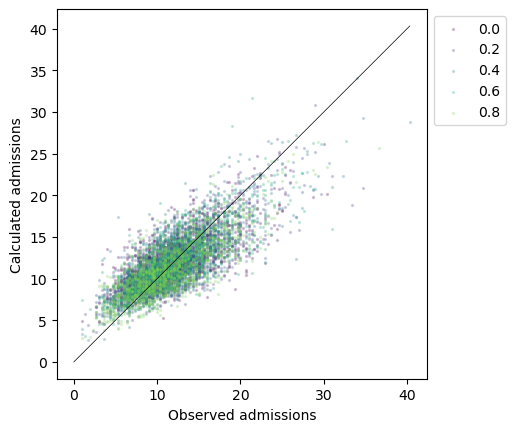

In [251]:
colours = plt.get_cmap('viridis')(np.linspace(0, 1, len(dict_quantiles)))

fig, ax = plt.subplots()

# Find max across both datasets:
ad_max = df_admissions_here[['admissions_predicted', 'admissions']].max().max_horizontal().to_numpy()[0]
print(ad_max)

# Equal line:
ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)

for q, q0 in enumerate(qmin_list):
    
    mask = df_admissions_here['depriv_quantile_min'] == q0
    df_here = df_admissions_here.filter(mask)
    ax.scatter(df_here['admissions'], df_here['admissions_predicted'], color=colours[q], s=2, alpha=0.2, label=q0)

ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')
ax.set_xlabel('Observed admissions')
ax.set_ylabel('Calculated admissions')
ax.set_aspect('equal')
plt.show()